# Supervised Audio Classification Model
This notebook trains a supervised Machine Learning model (Random Forest) on the separated audio clips.
Since we only have ~100 data points, extracting MFCC features and using a Random Forest is highly effective and avoids overfitting.

In [1]:
%pip install -q scikit-learn librosa pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Feature Extraction (MFCCs)
We will extract Mel-Frequency Cepstral Coefficients (MFCCs) which compactly represent the audio's frequency envelope over time.

In [3]:
def extract_mfcc(file_path, n_mfcc=40):
    try:
        y, sr = librosa.load(file_path, sr=22050)
        if len(y) == 0:
            return None
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        # Take the mean across the time axis
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        return mfccs_scaled
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None

## 2. Load Data and Labels
We will simulate loading labels. *Replace this logic with your actual labeling method* (e.g., reading from a CSV or checking folder names).
For demonstration, we assume all files in `Data/Output` are "gunshots" (Label 1), and files in another folder are "noise" (Label 0).

In [4]:
dataset_dir = r"c:\Desktop\Data-Cleaner\research\Data\Output\clips"
# If you don't have a noise folder yet, you can replace this with your actual CSV loading
audio_files = []
labels = []

if os.path.exists(dataset_dir):
    for f in os.listdir(dataset_dir):
        if f.endswith(".wav"):
            path = os.path.join(dataset_dir, f)
            audio_files.append(path)
            
            # Example heuristic: if filename contains "noise", label=0 (Noise), else label=1 (Gunshot)
            if "noise" in f.lower():
                labels.append(0)
            else:
                labels.append(1)

print(f"Found {len(audio_files)} audio files.")

Found 51 audio files.


In [5]:
features = []
valid_labels = []

print("Extracting features. This may take a minute...")
for f, label in zip(audio_files, labels):
    data = extract_mfcc(f)
    if data is not None:
        features.append(data)
        valid_labels.append(label)

X = np.array(features)
y = np.array(valid_labels)

print(f"Feature matrix shape: {X.shape}")
print(f"Labels distribution: {pd.Series(y).value_counts().to_dict()}")

Extracting features. This may take a minute...


d:\anaconda3\envs\LLM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature matrix shape: (51, 40)
Labels distribution: {1: 51}


## 3. Train the Model

In [6]:
# Split 80/20 for train/test
if len(X) > 5:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if len(set(y)) > 1 else None)
    
    # Initialize and Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    print("Model training complete!")
else:
    print("Not enough data to train. Please ensure you have extracted audio data.")

Model training complete!


## 4. Evaluation

Classification Report:

              precision    recall  f1-score   support

     Gunshot       1.00      1.00      1.00        11

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



d:\anaconda3\envs\LLM\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


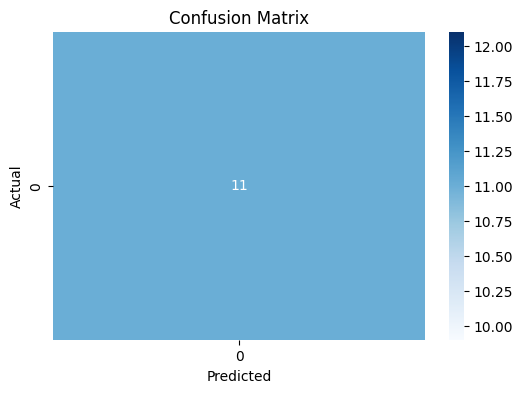

In [7]:
if len(X) > 5:
    predictions = rf_model.predict(X_test)
    
    # If you only have ONE class of data right now (e.g., everything is a gunshot), 
    # precision/recall metrics won't mean much until you add negative samples!
    print("Classification Report:\n")
    try:
        print(classification_report(y_test, predictions, target_names=["Noise", "Gunshot"] if len(set(y)) > 1 else ["Gunshot"]))
    except ValueError:
        print(classification_report(y_test, predictions))
        
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()